
 📊 สรุปภาพรวม PM 2.5 ในพื้นที่ (ตามมาตรฐาน AQI)
ระดับความอันตราย             | จำนวนครั้ง (นาที) | สัดส่วน (%)
-----------------------------------------------------------------
1. ดีมาก (Safe)              | 10549             | 8.12
2. ดี (Normal)               | 15780             | 12.15
3. ปานกลาง (Watch)           | 53616             | 41.27
4. เริ่มระวัง (Warning)      | 49368             | 38.0
5. อันตรายขึ้นไป (Danger)    | 608               | 0.47

 🔴 ตัวอย่าง 5 แถวแรก: เกณฑ์อันตรายขึ้นไป (>= 75.0)
Time                 | PM 2.5   | PM2.5_Safety_Level
-----------------------------------------------------------------
2026-02-14 20:20:00  | 80.67    | 5. อันตรายขึ้นไป (Danger)
2026-02-14 20:21:00  | 79.50    | 5. อันตรายขึ้นไป (Danger)
2026-02-18 23:05:00  | 75.83    | 5. อันตรายขึ้นไป (Danger)
2026-02-18 23:06:00  | 75.33    | 5. อันตรายขึ้นไป (Danger)
2026-02-18 23:10:00  | 75.00    | 4. เริ่มระวัง (Warning)

 🟠 ตัวอย่าง 5 แถวแรก: เกณฑ์เริ่มระวัง (Warning) (37.5 - 74.99)
Time   

C:\Users\HEY YOU COM\AppData\Local\Temp\ipykernel_15056\2362669114.py:114: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Tahoma.
  plt.tight_layout()
c:\Users\HEY YOU COM\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


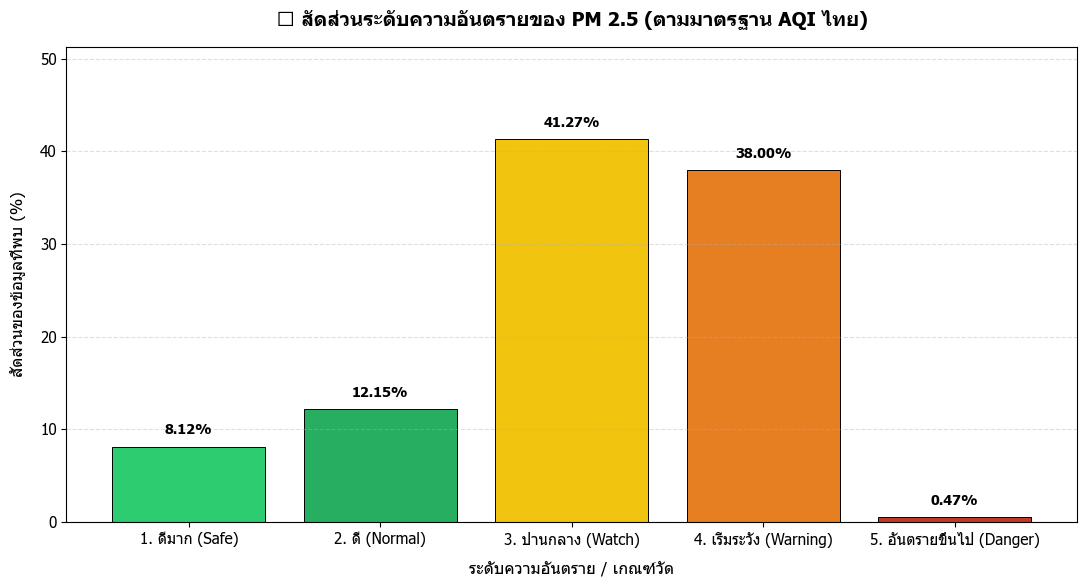

💾 บันทึกไฟล์ report.xlsx พร้อมตกแต่งตารางสวยงามเรียบร้อย!



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm  # 🛠️ แก้ไข: import font_manager ให้ถูกต้อง

# =======================================================
# 🛠️ จัดการฟอนต์ภาษาไทยอัตโนมัติ (ป้องกันฟอนต์สี่เหลี่ยม)
# =======================================================
font_list = ['Kanit', 'Sarabun', 'Tahoma', 'Leelawadee UI', 'Calibri', 'Arial']
selected_font = 'sans-serif'

# ค้นหาฟอนต์ไทยที่มีในเครื่อง
for f in font_list:
    if f in [font.name for font in fm.fontManager.ttflist]: # 🛠️ แก้ไขการเรียกใช้งานตรงนี้
        selected_font = f
        break

plt.rcParams['font.family'] = selected_font
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False 

# 1. โหลดข้อมูล และแปลงรูปแบบเวลาให้เป็นมาตรฐาน Datetime
df = pd.read_csv('Export.csv', skiprows=1)
df['Time'] = pd.to_datetime(df['Time']) 

# 2. ทำความสะอาดข้อมูล PM 2.5 (ตัดค่าที่น้อยกว่า 0 หรือมากกว่า 1000 ทิ้ง)
df.loc[(df['PM 2.5'] < 0) | (df['PM 2.5'] > 1000), 'PM 2.5'] = np.nan
df_clean = df.dropna(subset=['PM 2.5']).copy()

# 3. กำหนดช่วงตัวเลข (Bins) และป้ายระดับความอันตรายตามมาตรฐาน AQI ไทย
bins = [0, 15.0, 25.0, 37.5, 75.0, float('inf')]
labels = ['1. ดีมาก (Safe)', '2. ดี (Normal)', '3. ปานกลาง (Watch)', '4. เริ่มระวัง (Warning)', '5. อันตรายขึ้นไป (Danger)']

# 4. สร้างคอลัมน์กลุ่มความอันตราย
df_clean['PM2.5_Safety_Level'] = pd.cut(df_clean['PM 2.5'], bins=bins, labels=labels, include_lowest=True)

# 5. สรุปผลข้อมูล: คำนวณทั้ง "จำนวนครั้ง" และ "เปอร์เซ็นต์"
summary = df_clean['PM2.5_Safety_Level'].value_counts().sort_index().reset_index()
summary.columns = ['ระดับความอันตราย', 'จำนวนครั้งที่พบ (นาที)']
summary['สัดส่วน (%)'] = (summary['จำนวนครั้งที่พบ (นาที)'] / len(df_clean) * 100).round(2)

# =======================================================
# 🖨️ ส่วนของการแสดงผลข้อความบน Console
# =======================================================

print("\n" + "="*65)
print(" 📊 สรุปภาพรวม PM 2.5 ในพื้นที่ (ตามมาตรฐาน AQI)")
print("="*65)
print(f"{'ระดับความอันตราย':<28} | {'จำนวนครั้ง (นาที)':<17} | {'สัดส่วน (%)'}")
print("-" * 65)

for _, row in summary.iterrows():
    print(f"{str(row['ระดับความอันตราย']):<28} | {str(row['จำนวนครั้งที่พบ (นาที)']):<17} | {str(row['สัดส่วน (%)'])}")

# [กรองข้อมูลตัวอย่าง 3 ช่วงเพื่อแสดงบน Terminal]
df_watch = df_clean[(df_clean['PM 2.5'] >= 25.0) & (df_clean['PM 2.5'] < 37.5)]  
df_warning = df_clean[(df_clean['PM 2.5'] >= 37.5) & (df_clean['PM 2.5'] < 75.0)] 
df_danger = df_clean[df_clean['PM 2.5'] >= 75.0]                                 

print("\n" + "="*65)
print(" 🔴 ตัวอย่าง 5 แถวแรก: เกณฑ์อันตรายขึ้นไป (>= 75.0)")
print("="*65)
print(f"{'Time':<20} | {'PM 2.5':<8} | {'PM2.5_Safety_Level'}")
print("-" * 65)
for _, row in df_danger[['Time', 'PM 2.5', 'PM2.5_Safety_Level']].head(5).iterrows():
    pm25_str = f"{row['PM 2.5']:.2f}"
    print(f"{str(row['Time']):<20} | {pm25_str:<8} | {str(row['PM2.5_Safety_Level'])}")

print("\n" + "="*65)
print(" 🟠 ตัวอย่าง 5 แถวแรก: เกณฑ์เริ่มระวัง (Warning) (37.5 - 74.99)")
print("="*65)
print(f"{'Time':<20} | {'PM 2.5':<8} | {'PM2.5_Safety_Level'}")
print("-" * 65)
for _, row in df_warning[['Time', 'PM 2.5', 'PM2.5_Safety_Level']].head(5).iterrows():
    pm25_str = f"{row['PM 2.5']:.2f}"
    print(f"{str(row['Time']):<20} | {pm25_str:<8} | {str(row['PM2.5_Safety_Level'])}")

print("\n" + "="*65)
print(" 🟡 ตัวอย่าง 5 แถวแรก: เกณฑ์ปานกลาง (Watch) (25.0 - 37.49)")
print("="*65)
print(f"{'Time':<20} | {'PM 2.5':<8} | {'PM2.5_Safety_Level'}")
print("-" * 65)
for _, row in df_watch[['Time', 'PM 2.5', 'PM2.5_Safety_Level']].head(5).iterrows():
    pm25_str = f"{row['PM 2.5']:.2f}" #
    print(f"{str(row['Time']):<20} | {pm25_str:<8} | {str(row['PM2.5_Safety_Level'])}")
print("="*65 + "\n")
# =======================================================
# 📊 ส่วนของการสร้างและแสดงผลกราฟแท่ง
# =======================================================

plt.figure(figsize=(11, 6))

# กำหนดสีของแท่งกราฟให้สื่อความหมาย (เขียว -> แดง)
custom_colors = ['#2ECC71', '#27AE60', '#F1C40F', '#E67E22', '#C0392B']

# วาดกราฟแท่งแสดงสัดส่วน (%)
bars = plt.bar(summary['ระดับความอันตราย'], summary['สัดส่วน (%)'], color=custom_colors, edgecolor='black', linewidth=0.7)

# เขียนตัวเลขเปอร์เซ็นต์กำกับไว้ที่หัวแท่งกราฟ
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ตกแต่งองค์ประกอบของกราฟ
plt.title('📊 สัดส่วนระดับความอันตรายของ PM 2.5 (ตามมาตรฐาน AQI ไทย)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ระดับความอันตราย / เกณฑ์วัด', fontsize=12, labelpad=10)
plt.ylabel('สัดส่วนของข้อมูลที่พบ (%)', fontsize=12, labelpad=10)
plt.ylim(0, max(summary['สัดส่วน (%)']) + 10)  
plt.grid(axis='y', linestyle='--', alpha=0.4) 

# แสดงผลกราฟ
plt.tight_layout()
plt.show()
# =======================================================
# 💾 ส่วนของการบันทึกไฟล์ Excel (ปรับตารางให้สวยงาม ไฟล์เดียว)
# =======================================================
file_name = 'report.xlsx'

# 1. เซฟข้อมูลลง Excel แบบปกติก่อน
summary.to_excel(file_name, index=False, sheet_name='Summary_AQI')

# 2. ใช้ openpyxl โหลดไฟล์ขึ้นมาตกแต่งให้สวยงาม
try:
    from openpyxl import load_workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

    wb = load_workbook(file_name)
    ws = wb['Summary_AQI']

    # ตั้งค่าสไตล์: สีหัวตาราง และ เส้นขอบ
    header_fill = PatternFill(start_color='34495E', end_color='34495E', fill_type='solid') # สีเทาเข้ม
    header_font = Font(bold=True, color='FFFFFF') # ตัวหนาสีขาว
    thin_border = Border(left=Side(style='thin'), right=Side(style='thin'), top=Side(style='thin'), bottom=Side(style='thin'))
    center_align = Alignment(horizontal='center', vertical='center')

    # ชุดสีพาสเทลตามระดับความอันตราย AQI
    aqi_colors = {
        '1. ดีมาก (Safe)': 'E8F8F5',       # เขียวอ่อน
        '2. ดี (Normal)': 'D4EFDF',        # เขียว
        '3. ปานกลาง (Watch)': 'FCF3CF',     # เหลือง
        '4. เริ่มระวัง (Warning)': 'F5CBA7',  # ส้ม
        '5. อันตรายขึ้นไป (Danger)': 'FADBD8' # แดง
    }

    # ตกแต่งหัวตาราง (แถวที่ 1)
    for col in range(1, 4):
        cell = ws.cell(row=1, column=col)
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = center_align
        cell.border = thin_border

    # ตกแต่งข้อมูลด้านใน และใส่สีตามระดับความอันตราย
    for row in range(2, ws.max_row + 1):
        level_name = str(ws.cell(row=row, column=1).value)
        row_color = PatternFill(start_color=aqi_colors.get(level_name, 'FFFFFF'), 
                                end_color=aqi_colors.get(level_name, 'FFFFFF'), fill_type='solid')
        
        for col in range(1, 4):
            cell = ws.cell(row=row, column=col)
            cell.border = thin_border
            if col == 1:
                cell.fill = row_color # คอลัมน์แรกให้ใส่สี AQI
            else:
                cell.alignment = center_align # คอลัมน์ตัวเลขให้จัดกึ่งกลาง

    # ปรับความกว้างของคอลัมน์อัตโนมัติให้พอดีกับข้อความ
    for col in ws.columns:
        max_length = 0
        column = col[0].column_letter
        for cell in col:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        ws.column_dimensions[column].width = max_length + 5

    wb.save(file_name)
    print(f"💾 บันทึกไฟล์ {file_name} พร้อมตกแต่งตารางสวยงามเรียบร้อย!\n")

except ImportError:
    print(f"💾 บันทึกไฟล์ {file_name} สำเร็จ! (หากต้องการให้ตารางสวยงามขึ้น แนะนำให้ติดตั้ง pip install openpyxl)\n")